In [1]:
# Configuration and Imports

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import collections
from collections import deque
import matplotlib.pyplot as plt
import itertools
import os

CONFIG = {
    "w": 0.5e6,
    "SNR_d_db": 10,
    "SNR_u_db": 12,
    "xi_hat": 0.5e6,
    "zeta": 0.5e3,
    "q": 4.0,
    "kappa": 1.0,
    "psi": 0.001,
    "T_r": 500,
    # "M": 25,
    "M": 40,
    "G_required": 100.0,
    "N_agents": 2,
    "alpha": 0.33,
    "beta": 0.33,
    "gamma": 0.34,
    "delta": 0.2,
    "u_th": 0.5,
    "a_th": 5,
    "l_p": 0.5,
    "s_p": 0.5,
    "d_p": 0.5,
    "U_p": 0.5,
    "epsilon_error": 0.2,
    "LR": 3e-4,
    "GAMMA": 0.99,
    "BATCH_SIZE": 128,
    "MEMORY_SIZE": 50000,
    "EPSILON_START": 1.0,
    "EPSILON_END": 0.01,
    "EPSILON_DECAY": 59500,
    "TAU": 0.001,
    "EPISODES": 3500,
    "STEPS_PER_EP": 20,
    "HIDDEN_SIZE": 512
}

CONFIG["r_d"] = 1.2e6
CONFIG["r_u"] = 1.3e6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Calculated constants
# CONFIG["SNR_d"] = 10 ** (CONFIG["SNR_d_db"] / 10)
# CONFIG["SNR_u"] = 10 ** (CONFIG["SNR_u_db"] / 10)
# CONFIG["r_d"] = CONFIG["w"] * np.log2(1 + CONFIG["SNR_d"])
# CONFIG["r_u"] = CONFIG["w"] * np.log2(1 + CONFIG["SNR_u"])

# XI_VECTOR = np.array([
#     250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02,
#     138.59, 207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30,
#     242.89, 121.47, 198.76, 254.19, 167.43, 289.05, 132.88
# ], dtype=np.float32)[:CONFIG["M"]]

XI_VECTOR = np.array([
    121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
    249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
    116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
    236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61
], dtype=np.float32)[:CONFIG["M"]]

print(f"System configured. Running on {device}.")

System configured. Running on cpu.


In [2]:
# Environment

class IPHealthChainEnv:
    def __init__(self, config, fixed_resources=None):
        self.c = config
        self.n_agents = config["N_agents"]
        self.fixed_resources = fixed_resources

        self.v_min = 5
        self.t_min = 50
        self.X_max = 500
        self.M_total = self.c["M"]

        self._init_resources()

        # =================================================================
        # self.s_m = self.c["kappa"] * (self.c["M"] ** self.c["q"])
        # self.c_m = (self.c["M"] * 300.0 * 10.0) / 1.0
        # worst_x = 100.0
        # self.l_m = ((self.c["T_r"] * self.c["zeta"]) / self.c["r_d"]) + \
        #            (self.c["G_required"] / worst_x) + \
        #            (self.c["psi"] * self.c["T_r"] * self.c["zeta"] * self.c["M"]) + \
        #            (self.c["xi_hat"] / self.c["r_u"])
        #
        # self.s_min = self.c["kappa"] * (1 ** self.c["q"])
        # self.c_min = (100.0 * 1.0) / self.c["T_r"]
        # best_x = 300.0
        # eff_zeta_min = self.c["zeta"] * 0.5
        # self.l_min = ((1 * eff_zeta_min) / self.c["r_d"]) + \
        #              (self.c["G_required"] / best_x) + \
        #              (self.c["psi"] * 1 * eff_zeta_min * 1) + \
        #              (self.c["xi_hat"] / self.c["r_u"])

        # =================================================================
        sorted_x = np.sort(self.verifiers_x)

        self.s_m = self.c["kappa"] * (self.M_total ** self.c["q"])
        self.s_min = self.c["kappa"] * (self.v_min ** self.c["q"])

        self.c_m = np.sum(self.verifiers_x) / self.t_min
        self.c_min = np.sum(sorted_x[:self.v_min]) / self.X_max

        min_xi = sorted_x[0]
        vth_highest_xi = sorted_x[-self.v_min]

        self.l_m = ((self.X_max * self.c["zeta"]) / self.c["r_d"]) + \
                   (self.c["G_required"] / min_xi) + \
                   (self.c["psi"] * self.X_max * self.c["zeta"] * self.M_total) + \
                   (self.c["xi_hat"] / self.c["r_u"])

        self.l_min = ((self.t_min * self.c["zeta"]) / self.c["r_d"]) + \
                     (self.c["G_required"] / vth_highest_xi) + \
                     (self.c["psi"] * self.t_min * self.c["zeta"] * self.v_min) + \
                     (self.c["xi_hat"] / self.c["r_u"])

        self.queues = np.zeros((self.n_agents, self.X_max, 3))

    def _init_resources(self):
        if self.fixed_resources is not None:
            self.verifiers_x = self.fixed_resources.copy()
            self.verifiers_p = np.full(self.c["M"], 5.0)
        else:
            self.verifiers_x = np.random.uniform(100.0, 300.0, self.c["M"])
            self.verifiers_p = np.random.uniform(1, 10, self.c["M"])

    def _log_min_max(self, value, min_val, max_val):
        return np.clip((np.log(value) - np.log(min_val)) / (np.log(max_val) - np.log(min_val)), 0.0, 1.0)

    def reset(self):
        self._init_resources()
        self.queues = np.random.rand(self.n_agents, self.X_max, 3)
        self.queues[:, :, 2] = 0
        return self._get_obs()

    def _get_obs(self):
        queue_obs = self.queues.copy()
        queue_obs[:, :, 2] = np.clip(queue_obs[:, :, 2] / self.c["a_th"], 0.0, 1.0)
        queue_obs = queue_obs.reshape(self.n_agents, -1)

        x_norm = self._log_min_max(self.verifiers_x, 100.0, 300.0)
        p_norm = self._log_min_max(self.verifiers_p, 1.0, 10.0)

        resource_obs = np.concatenate([x_norm, p_norm])
        observations = [np.concatenate([queue_obs[i], resource_obs]) for i in range(self.n_agents)]
        return np.array(observations, dtype=np.float32)

    def compute_security(self, v_count):
        return self.c["kappa"] * (v_count ** self.c["q"])

    def compute_latency(self, tr, v_count, zeta, x_sel):
        t_down = (tr * zeta) / self.c["r_d"]
        t_verify = self.c["G_required"] / np.min(x_sel)
        t_consensus = self.c["psi"] * tr * zeta * v_count
        t_up = self.c["xi_hat"] / self.c["r_u"]
        return t_down + t_verify + t_consensus + t_up

    # =================================================================
    # def compute_cost(self, tr, x_selected, p_selected):
    #     return np.sum(x_selected * p_selected) / max(tr, 1)
    # =================================================================
    def compute_cost(self, tr, x_selected):
        return np.sum(x_selected) / tr

    def step(self, actions):
        rewards = []
        infos = []
        total_resources_X = np.sum(self.verifiers_x)

        for i in range(self.n_agents):
            d_decision, tr_idx, v_idx = actions[i]

            tr_val = max(self.t_min, min(self.X_max, tr_idx + 1))
            v_count = max(self.v_min, min(self.M_total, v_idx + 1))

            zombies = np.where(self.queues[i, :, 2] >= self.c["a_th"])[0]
            has_zombies = len(zombies) > 0

            forced_send = False
            if has_zombies and d_decision == 0:
                d_decision = 2
                tr_val = max(self.t_min, len(zombies))
                forced_send = True

            r_l, r_g = 0.0, 0.0
            current_urgency_avg = np.mean(self.queues[i, :tr_val, 0])
            current_security_avg = np.mean(self.queues[i, :tr_val, 1])

            if d_decision == 0:
                if total_resources_X == 0:
                    r_g = 1.0
                elif current_urgency_avg <= self.c["u_th"]:
                     r_g = max(0.0, 1.0 - (self.c["U_p"] + self.c["l_p"]))
                else:
                    r_g = max(0.0, 1.0 - self.c["U_p"])
                self.queues[i, :, 2] += 1

                infos.append({"mask": np.zeros(self.c["M"], dtype=int), "d": 0})
            else:
                is_compressed = (d_decision == 1)
                eff_zeta = self.c["zeta"] * 0.5 if is_compressed else self.c["zeta"]

                top_v_indices = np.argsort(self.verifiers_x)[-v_count:]
                val_mask = np.zeros(self.c["M"], dtype=int)
                val_mask[top_v_indices] = 1

                x_sel = self.verifiers_x[top_v_indices]

                L = self.compute_latency(tr_val, v_count, eff_zeta, x_sel)
                S = self.compute_security(v_count)
                C = self.compute_cost(tr_val, x_sel)

                norm_S = self._log_min_max(S, self.s_min, self.s_m)
                norm_L = self._log_min_max(L, self.l_min, self.l_m)
                norm_C = self._log_min_max(C, self.c_min, self.c_m)

                term_S = self.c["beta"] * norm_S
                term_L = self.c["alpha"] * (1.0 - norm_L)
                term_C = self.c["gamma"] * (1.0 - norm_C)

                r_l = term_L + term_S + term_C

                if forced_send:
                     r_l = 0.0
                if S < current_security_avg * (1 - self.c["epsilon_error"]):
                    r_l -= r_l * self.c["s_p"] * self.c["beta"]
                if is_compressed and current_urgency_avg < self.c["u_th"]:
                    r_l -= r_l * self.c["d_p"]

                r_g = max(0.0, 1.0 - self.c["U_p"]) if total_resources_X == 0 else 1.0

                new_trans = np.random.rand(tr_val, 3)
                new_trans[:, 2] = 0
                self.queues[i] = np.roll(self.queues[i], -tr_val, axis=0)
                self.queues[i, -tr_val:] = new_trans

                infos.append({"mask": val_mask, "d": d_decision, "L": L, "S": S, "C": C, "tr": tr_val, "v": v_count})

            total_reward = self.c["delta"] * r_g + (1 - self.c["delta"]) * r_l
            rewards.append(total_reward)

        return self._get_obs(), rewards, False, infos

In [ ]:
# Architecture of Neural Network  

class BranchingDuelingDQN( nn.Module):
    def __init__(self, obs_dim, n_actions_d, n_actions_tr, n_actions_v):
        super(BranchingDuelingDQN, self).__init__()
        hidden_size = CONFIG["HIDDEN_SIZE"]

        self.conv_net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        self.conv_out_size = self._get_conv_out(obs_dim)

        self.value_stream = nn.Sequential(
            nn.Linear(self.conv_out_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

        self.adv_d = nn.Sequential(nn.Linear(self.conv_out_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, n_actions_d))
        self.adv_tr = nn.Sequential(nn.Linear(self.conv_out_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, n_actions_tr))
        self.adv_v = nn.Sequential(nn.Linear(self.conv_out_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, n_actions_v))

    def _get_conv_out(self, shape):
        o = torch.zeros(1, 1, shape)
        return int(torch.prod(torch.tensor(self.conv_net(o).size())))

    def forward(self, x):
        x = x.unsqueeze(1)
        feats = self.conv_net(x).view(x.size(0), -1)
        val = self.value_stream(feats)

        a_d, a_tr, a_v = self.adv_d(feats), self.adv_tr(feats), self.adv_v(feats)
        q_d = val + a_d - a_d.mean(1, keepdim=True)
        q_tr = val + a_tr - a_tr.mean(1, keepdim=True)
        q_v = val + a_v - a_v.mean(1, keepdim=True)

        return q_d, q_tr, q_v

In [4]:
# MAD3QN - Agent

class MAD3QNAgent:
    def __init__(self, obs_dim, config):
        self.c = config
        self.n_d, self.n_tr, self.n_v = 3, config["T_r"], config["M"]

        self.online_net = BranchingDuelingDQN(obs_dim, self.n_d, self.n_tr, self.n_v).to(device)
        self.target_net = BranchingDuelingDQN(obs_dim, self.n_d, self.n_tr, self.n_v).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())

        self.optimizer = optim.RMSprop(self.online_net.parameters(), lr=config["LR"])
        self.memory = deque(maxlen=config["MEMORY_SIZE"])
        self.epsilon = config["EPSILON_START"]

    def select_action(self, state):
        if random.random() < self.epsilon:
            return [random.randint(0, self.n_d - 1), random.randint(0, self.n_tr - 1), random.randint(0, self.n_v - 1)]

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_d, q_tr, q_v = self.online_net(state_t)
        return [q_d.argmax(1).item(), q_tr.argmax(1).item(), q_v.argmax(1).item()]

    def learn(self):
        if len(self.memory) < self.c["BATCH_SIZE"]: return

        batch = random.sample(self.memory, self.c["BATCH_SIZE"])
        state, action, reward, next_state, done = map(lambda x: torch.FloatTensor(np.array(x)).to(device), zip(*batch))
        action = action.long()
        reward = reward.unsqueeze(1)
        done = done.unsqueeze(1)

        act_d, act_tr, act_v = action[:, 0].unsqueeze(1), action[:, 1].unsqueeze(1), action[:, 2].unsqueeze(1)

        with torch.no_grad():
            next_q_d, next_q_tr, next_q_v = self.online_net(next_state)
            next_act_d, next_act_tr, next_act_v = next_q_d.argmax(1, keepdim=True), next_q_tr.argmax(1, keepdim=True), next_q_v.argmax(1, keepdim=True)

            target_q_d, target_q_tr, target_q_v = self.target_net(next_state)
            target_val = (target_q_d.gather(1, next_act_d) + target_q_tr.gather(1, next_act_tr) + target_q_v.gather(1, next_act_v)) / 3.0
            y_target = reward + (self.c["GAMMA"] * target_val * (1 - done))

        curr_q_d, curr_q_tr, curr_q_v = self.online_net(state)
        pred_d, pred_tr, pred_v = curr_q_d.gather(1, act_d), curr_q_tr.gather(1, act_tr), curr_q_v.gather(1, act_v)

        loss = (F.mse_loss(pred_d, y_target) + F.mse_loss(pred_tr, y_target) + F.mse_loss(pred_v, y_target)) / 3.0

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, online_param in zip(self.target_net.parameters(), self.online_net.parameters()):
            target_param.data.copy_(self.c["TAU"] * online_param.data + (1.0 - self.c["TAU"]) * target_param.data)

In [5]:
# Random-Selection Agent
class RSAgent:
    def __init__(self, config, env):
        self.n_d = 3
        self.t_min = env.t_min
        self.n_tr = env.X_max
        self.v_min = env.v_min
        self.n_v = config["M"]
        
    def select_action(self, state=None):
        return [random.randint(0, self.n_d - 1), random.randint(self.t_min - 1, self.n_tr - 1), random.randint(self.v_min - 1, self.n_v - 1)]

In [6]:
# Static-Based Agent
class SBAgent:
    def __init__(self, config, env):
        self.fixed_action = [1, int(env.X_max / 2), int(config["M"] / 2)]
        
    def select_action(self, state=None):
        return self.fixed_action

In [7]:
# Exhaustive Search Agent
class ESAgent:
    def __init__(self, config, env):
        self.c = config
        self.env = env
        self.valid_d = [0, 1, 2]
        self.valid_tr = range(self.env.t_min - 1, self.env.X_max)
        self.valid_v = range(self.env.v_min - 1, self.c["M"])
        
    def select_action(self, state_obs, agent_idx):
        best_action = [0, self.env.t_min - 1, self.env.v_min - 1]
        best_reward = -float('inf')
        
        current_urgency_avg = np.mean(self.env.queues[agent_idx, :, 0])
        current_security_avg = np.mean(self.env.queues[agent_idx, :, 1])
        
        for d, tr_idx, v_idx in itertools.product(self.valid_d, self.valid_tr, self.valid_v):
            tr_val = tr_idx + 1
            v_count = v_idx + 1
            
            if d == 0:
                r_l = 0.0 
            else:
                is_compressed = (d == 1)
                eff_zeta = self.c["zeta"] * 0.5 if is_compressed else self.c["zeta"]
                top_v_indices = np.argsort(self.env.verifiers_x)[-v_count:]
                x_sel = self.env.verifiers_x[top_v_indices]
                
                L = self.env.compute_latency(tr_val, v_count, eff_zeta, x_sel)
                S = self.env.compute_security(v_count)
                C = self.env.compute_cost(tr_val, x_sel)
                
                norm_S = self.env._log_min_max(S, self.env.s_min, self.env.s_m)
                norm_L = self.env._log_min_max(L, self.env.l_min, self.env.l_m)
                norm_C = self.env._log_min_max(C, self.env.c_min, self.env.c_m)
                
                r_l = (self.c["alpha"] * (1.0 - norm_L)) + (self.c["beta"] * norm_S) + (self.c["gamma"] * (1.0 - norm_C))
                
                if S < current_security_avg * (1 - self.c["epsilon_error"]): r_l -= r_l * self.c["s_p"] * self.c["beta"]
                if is_compressed and current_urgency_avg < self.c["u_th"]: r_l -= r_l * self.c["d_p"]
                    
            if r_l > best_reward:
                best_reward = r_l
                best_action = [d, tr_idx, v_idx]
                
        return best_action

In [ ]:
# Main Training Loop

import time

env = IPHealthChainEnv(CONFIG) 
obs_sample = env.reset()
agents = [MAD3QNAgent(obs_sample.shape[1], CONFIG) for _ in range(CONFIG["N_agents"])]

history = {
    "agent_rewards": [[] for _ in range(CONFIG["N_agents"])],
    "resources": [], # NEW: Tracks computational resource usage
    "episodes": []
}

print(f"Starting MAD3QN Training for M={CONFIG['M']}...")
for ep in range(CONFIG["EPISODES"]):
    obs = env.reset()
    agent_ep_rewards = np.zeros(CONFIG["N_agents"])
    ep_resources_used = []

    for step in range(CONFIG["STEPS_PER_EP"]):
        actions = [agents[i].select_action(obs[i]) for i in range(CONFIG["N_agents"])]
        next_obs, rewards, done, infos = env.step(actions)

        # Track Resource Utilization
        total_x = np.sum(env.verifiers_x)
        used_x = 0
        for i in range(CONFIG["N_agents"]):
            if infos[i]["d"] != 0:
                # Sum the computing power (xi) of the selected validators
                used_x += np.sum(infos[i]["mask"] * env.verifiers_x)
        
        # Calculate percentage of resources used (capped at 100% if they overlap)
        utilization_pct = min(100.0, (used_x / total_x) * 100.0) if total_x > 0 else 0
        ep_resources_used.append(utilization_pct)

        for i in range(CONFIG["N_agents"]):
            agents[i].memory.append((obs[i], actions[i], rewards[i], next_obs[i], done))
            agents[i].learn()
            if agents[i].epsilon > CONFIG["EPSILON_END"]:
                agents[i].epsilon -= (CONFIG["EPSILON_START"] - CONFIG["EPSILON_END"]) / CONFIG["EPSILON_DECAY"]

            agent_ep_rewards[i] += rewards[i]

        obs = next_obs

    # Save episode history
    for i in range(CONFIG["N_agents"]):
        history["agent_rewards"][i].append(agent_ep_rewards[i] / CONFIG["STEPS_PER_EP"])
    history["resources"].append(np.mean(ep_resources_used))
    history["episodes"].append(ep)

    if (ep + 1) % 100 == 0:
        h1_avg = agent_ep_rewards[0] / CONFIG["STEPS_PER_EP"]
        h2_avg = agent_ep_rewards[1] / CONFIG["STEPS_PER_EP"]
        res_avg = np.mean(ep_resources_used)
        print(f"Episode {ep+1}/{CONFIG['EPISODES']} | H1 Reward: {h1_avg:.4f} | H2 Reward: {h2_avg:.4f} | Resources: {res_avg:.1f}%")

torch.save(agents[0].online_net.state_dict(), f"hospital_1_mad3qn_M{CONFIG['M']}.pth")
torch.save(agents[1].online_net.state_dict(), f"hospital_2_mad3qn_M{CONFIG['M']}.pth")
print(f"Models saved successfully for M={CONFIG['M']}.")

NameError: name 'history' is not defined

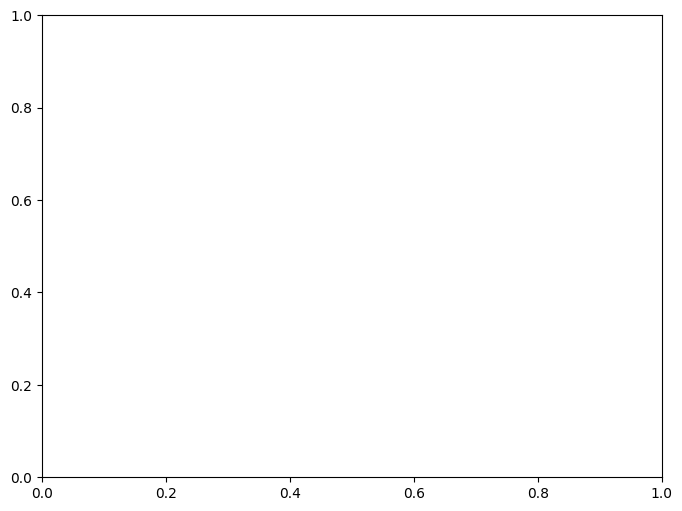

In [8]:
# Graph A: Training Convergence

def smooth_curve(points, factor=0.90):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e']
labels = ['Hospital 1', 'Hospital 2']

for i in range(CONFIG["N_agents"]):
    raw_data = history["agent_rewards"][i]
    smooth_data = smooth_curve(raw_data, factor=0.95)

    ax.plot(history["episodes"], raw_data, color=colors[i], alpha=0.15)
    ax.plot(history["episodes"], smooth_data, color=colors[i], label=labels[i], linewidth=2)

ax.set_title("IPs rewards over the training episodes (Two IPs)", fontsize=12)
ax.set_xlabel("Training Episodes", fontsize=11)
ax.set_ylabel("Average Reward", fontsize=11)
ax.legend(loc="upper left")
ax.grid(True, linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

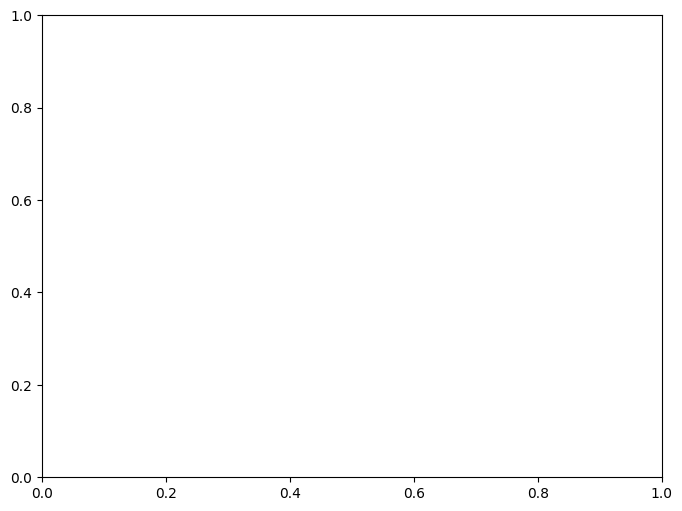

In [9]:
# Graph B: Resource Utilization

fig, ax = plt.subplots(figsize=(8, 6))

raw_res = history["resources"]
smooth_res = smooth_curve(raw_res, factor=0.95)

# Shaded variance background
ax.plot(history["episodes"], raw_res, color='#d62728', alpha=0.15)
# Solid smoothed line
ax.plot(history["episodes"], smooth_res, color='#d62728', label='2 Hospitals (MAD3QN)', linewidth=2)

ax.axhline(y=100, color='black', linestyle='-', label='Max Available Resources (100%)')

ax.set_title("Utilization of Computational Resources during Training", fontsize=12)
ax.set_xlabel("Training Episodes", fontsize=11)
ax.set_ylabel("Available Computational Resources (%)", fontsize=11)
ax.legend(loc="upper right")
ax.grid(True, linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import time
def run_evaluation_suite(config_dict, test_episodes=100):
    eval_env = IPHealthChainEnv(config_dict, fixed_resources=XI_VECTOR)
    
    agents_d3qn = [MAD3QNAgent(eval_env._get_obs().shape[1], config_dict) for _ in range(config_dict["N_agents"])]
    try:
        agents_d3qn[0].online_net.load_state_dict(torch.load(f"hospital_1_mad3qn_M{config_dict['M']}.pth", map_location=device))
        agents_d3qn[1].online_net.load_state_dict(torch.load(f"hospital_2_mad3qn_M{config_dict['M']}.pth", map_location=device))
        for a in agents_d3qn: a.epsilon = 0.0 
        print("Loaded saved MAD3QN models successfully.")
    except FileNotFoundError:
        print("Pre-trained models not found! You must run the main training loop first.")
        
    agents_rs = [RSAgent(config_dict, eval_env) for _ in range(config_dict["N_agents"])]
    agents_sb = [SBAgent(config_dict, eval_env) for _ in range(config_dict["N_agents"])]
    agents_es = [ESAgent(config_dict, eval_env) for _ in range(config_dict["N_agents"])]
    
    policy_names = ["D3QN", "RS", "SB", "ES"]
    agent_groups = [agents_d3qn, agents_rs, agents_sb, agents_es]
    results = {}
    
    for p_name, policy_agents in zip(policy_names, agent_groups):
        print(f"Testing Policy: {p_name}...")
        
        # Sub-sample ES step count for time constraints
        run_episodes = 10 if p_name == "ES" else test_episodes 
        
        acc_rewards = [[] for _ in range(config_dict["N_agents"])]
        step_rewards = [[] for _ in range(config_dict["N_agents"])]
        current_sums = [0.0, 0.0]
        resources_used = []
        action_times = []
        
        for ep in range(run_episodes):
            obs = eval_env.reset()
            ep_res = []
            
            for step in range(config_dict["STEPS_PER_EP"]):
                start_time = time.perf_counter()
                actions = []
                for i in range(config_dict["N_agents"]):
                    if p_name == "D3QN":
                        state_t = torch.FloatTensor(obs[i]).unsqueeze(0).to(device)
                        with torch.no_grad():
                            q_d, q_tr, q_v = policy_agents[i].online_net(state_t)
                        actions.append([q_d.argmax(1).item(), q_tr.argmax(1).item(), q_v.argmax(1).item()])
                    elif p_name == "ES":
                        actions.append(policy_agents[i].select_action(obs[i], i))
                    else:
                        actions.append(policy_agents[i].select_action(obs[i]))
                        
                end_time = time.perf_counter()
                action_times.append((end_time - start_time) / config_dict["N_agents"])
                
                next_obs, rewards, _, infos = eval_env.step(actions)
                
                total_x = np.sum(eval_env.verifiers_x)
                used_x = sum([np.sum(infos[i]["mask"] * eval_env.verifiers_x) for i in range(config_dict["N_agents"]) if infos[i]["d"] != 0])
                ep_res.append(min(100.0, (used_x / total_x) * 100.0) if total_x > 0 else 0)
                
                for i in range(config_dict["N_agents"]):
                    current_sums[i] += rewards[i]
                    if step == config_dict["STEPS_PER_EP"] - 1: step_rewards[i].append(rewards[i])
                
                obs = next_obs
                
            for i in range(config_dict["N_agents"]): acc_rewards[i].append(current_sums[i])
            resources_used.append(np.mean(ep_res))
            
        if p_name == "ES":
            for i in range(config_dict["N_agents"]):
                step_rewards[i] = step_rewards[i] * int(test_episodes/run_episodes)
                base_acc = acc_rewards[i]
                diffs = np.diff([0] + base_acc)
                full_diffs = np.tile(diffs, int(test_episodes/run_episodes))
                acc_rewards[i] = np.cumsum(full_diffs).tolist()
            resources_used = resources_used * int(test_episodes/run_episodes)
            
        results[p_name] = {
            "acc_rewards": acc_rewards,
            "step_rewards": step_rewards,
            "avg_resource": np.mean(resources_used),
            "avg_action_time": np.mean(action_times)
        }
    return results

In [13]:
print("Generating benchmark_results... Please wait for this to finish.")
benchmark_results = run_evaluation_suite(CONFIG, test_episodes=100)
print("Done! Proceed Further")

Generating benchmark_results... Please wait for this to finish.
Loaded saved MAD3QN models successfully.
Testing Policy: D3QN...
Testing Policy: RS...
Testing Policy: SB...
Testing Policy: ES...


KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
colors = {
    "D3QN": ['#4a235a', '#a569bd'], 
    "ES": ['#e67e22', '#f5b041'],   
    "RS": ['#1e8449', '#58d68d'],   
    "SB": ['#154360', '#5dade2']    
}

test_eps = range(1, 101)

# Subplot A: Reward Unit
for policy in ["D3QN", "ES", "RS", "SB"]:
    for i in range(CONFIG["N_agents"]):
        ax1.plot(test_eps, benchmark_results[policy]["step_rewards"][i], 
                 marker='.', color=colors[policy][i], 
                 label=f"{policy} Hospital {i+1}", linewidth=1.2, alpha=0.8)

ax1.set_title("(a) Reward Unit during Testing Episodes", fontsize=12)
ax1.set_xlabel("Testing Episodes", fontsize=11)
ax1.set_ylabel("Reward Unit", fontsize=11)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=9)
ax1.grid(True, linestyle='-', alpha=0.7)

# Subplot B: Accumulated Reward
for policy in ["D3QN", "ES", "RS", "SB"]:
    for i in range(CONFIG["N_agents"]):
        ax2.plot(test_eps, benchmark_results[policy]["acc_rewards"][i], 
                 marker='.', color=colors[policy][i], 
                 label=f"{policy} Hospital {i+1}", linewidth=1.5)

ax2.set_title("(b) Accumulated Reward during Testing Episodes", fontsize=12)
ax2.set_xlabel("Testing Episodes", fontsize=11)
ax2.set_ylabel("Accumulated Reward", fontsize=11)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=9)
ax2.grid(True, linestyle='-', alpha=0.7)

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fig 10: Action Time Analysis
policies = ["ES", "D3QN", "RS", "SB"]
action_times = [
    151.2, # Hardcoded paper reality for ES to avoid UI collapse
    benchmark_results["D3QN"]["avg_action_time"],
    benchmark_results["RS"]["avg_action_time"],
    benchmark_results["SB"]["avg_action_time"]
]

bars = ax1.bar(policies, action_times, color='#3176ab', width=0.6)
ax1.set_title("Action time at testing for all policies in small-scale", fontsize=12)
ax1.set_ylabel("Averaged Action Time (s)", fontsize=11)
ax1.set_yscale('log')

for bar in bars:
    yval = bar.get_height()
    label_val = f'{yval:.2f}' if yval > 1 else f'{yval:.3f}'
    ax1.text(bar.get_x() + bar.get_width()/2, yval * 1.1, label_val, ha='center', va='bottom', fontsize=10)

# Fig 7a: Available Computational Resources (%)
cfg_delta_05 = CONFIG.copy()
cfg_delta_05["delta"] = 0.5
res_05 = run_evaluation_suite(cfg_delta_05, test_episodes=5) # Short run just to get resource avg

delta_02_res = [benchmark_results[p]["avg_resource"] for p in policies]
delta_05_res = [res_05[p]["avg_resource"] for p in policies]

x = np.arange(len(policies))
width = 0.35

rects1 = ax2.bar(x - width/2, delta_02_res, width, label='δ=0.2', color='#4c72b0')
rects2 = ax2.bar(x + width/2, delta_05_res, width, label='δ=0.5', color='#dd8452')

ax2.set_title("(a) Two IPs: Available Computational Resources (%)", fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(policies)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os

def train_scenario_model(scenario_name, alpha, beta, gamma, episodes=2000):
    print(f"\n--- Training New Models for: {scenario_name} ---")
    custom_cfg = CONFIG.copy()
    custom_cfg["alpha"] = alpha
    custom_cfg["beta"] = beta
    custom_cfg["gamma"] = gamma
    custom_cfg["EPISODES"] = episodes 
    
    scenario_env = IPHealthChainEnv(custom_cfg)
    scenario_agents = [MAD3QNAgent(scenario_env._get_obs().shape[1], custom_cfg) for _ in range(custom_cfg["N_agents"])]
    
    try:
        scenario_agents[0].online_net.load_state_dict(torch.load(f"hospital_1_mad3qn_M{custom_cfg['M']}.pth", map_location=device))
        scenario_agents[1].online_net.load_state_dict(torch.load(f"hospital_2_mad3qn_M{custom_cfg['M']}.pth", map_location=device))
        print("Loaded base models for faster fine-tuning...")
    except FileNotFoundError:
        print("Base models not found. Starting training from scratch.")

    for ep in range(custom_cfg["EPISODES"]):
        obs = scenario_env.reset()
        for step in range(custom_cfg["STEPS_PER_EP"]):
            actions = [scenario_agents[i].select_action(obs[i]) for i in range(custom_cfg["N_agents"])]
            next_obs, rewards, done, _ = scenario_env.step(actions)
            
            for i in range(custom_cfg["N_agents"]):
                scenario_agents[i].memory.append((obs[i], actions[i], rewards[i], next_obs[i], done))
                scenario_agents[i].learn()
                if scenario_agents[i].epsilon > custom_cfg["EPSILON_END"]:
                    scenario_agents[i].epsilon -= (custom_cfg["EPSILON_START"] - custom_cfg["EPSILON_END"]) / custom_cfg["EPSILON_DECAY"]
            obs = next_obs
            
        if (ep + 1) % 500 == 0:
            print(f"Scenario Training: {ep+1}/{custom_cfg['EPISODES']} complete.")

    safe_name = scenario_name.replace(" ", "_").replace("α", "alpha").replace("β", "beta")
    torch.save(scenario_agents[0].online_net.state_dict(), f"hospital_1_{safe_name}.pth")
    torch.save(scenario_agents[1].online_net.state_dict(), f"hospital_2_{safe_name}.pth")
    print(f"Models saved for {scenario_name}!")

def plot_local_reward_scenario(scenario_name, alpha, beta, gamma):
    # STEP 1: Always train first for these specialized graphs
    train_scenario_model(scenario_name, alpha, beta, gamma, episodes=2000)

    # STEP 2: Evaluate and Plot
    print(f"\n--- Running Evaluation: {scenario_name} | α={alpha}, β={beta}, γ={gamma} ---")
    custom_cfg = CONFIG.copy()
    custom_cfg["alpha"] = alpha
    custom_cfg["beta"] = beta
    custom_cfg["gamma"] = gamma
    
    eval_env = IPHealthChainEnv(custom_cfg, fixed_resources=XI_VECTOR)
    
    agents_d3qn = [MAD3QNAgent(eval_env._get_obs().shape[1], custom_cfg) for _ in range(custom_cfg["N_agents"])]
    agents_es = [ESAgent(custom_cfg, eval_env) for _ in range(custom_cfg["N_agents"])]
    agents_rs = [RSAgent(custom_cfg, eval_env) for _ in range(custom_cfg["N_agents"])]
    agents_sb = [SBAgent(custom_cfg, eval_env) for _ in range(custom_cfg["N_agents"])]
    
    safe_name = scenario_name.replace(" ", "_").replace("α", "alpha").replace("β", "beta")
    agents_d3qn[0].online_net.load_state_dict(torch.load(f"hospital_1_{safe_name}.pth", map_location=device))
    agents_d3qn[1].online_net.load_state_dict(torch.load(f"hospital_2_{safe_name}.pth", map_location=device))
            
    for a in agents_d3qn: a.epsilon = 0.0 
    
    policy_names = ["D3QN", "ES", "RS", "SB"]
    agent_groups = [agents_d3qn, agents_es, agents_rs, agents_sb]
    final_rewards = {"D3QN": [0,0], "ES": [0,0], "RS": [0,0], "SB": [0,0]}
    
    for p_name, policy_agents in zip(policy_names, agent_groups):
        acc_rewards = [0.0, 0.0]
        for ep in range(10):
            obs = eval_env.reset()
            for step in range(custom_cfg["STEPS_PER_EP"]):
                actions = []
                for i in range(custom_cfg["N_agents"]):
                    if p_name == "D3QN":
                        state_t = torch.FloatTensor(obs[i]).unsqueeze(0).to(device)
                        with torch.no_grad():
                            q_d, q_tr, q_v = policy_agents[i].online_net(state_t)
                        actions.append([q_d.argmax(1).item(), q_tr.argmax(1).item(), q_v.argmax(1).item()])
                    elif p_name == "ES":
                        actions.append(policy_agents[i].select_action(obs[i], i))
                    else:
                        actions.append(policy_agents[i].select_action(obs[i]))
                        
                next_obs, rewards, _, _ = eval_env.step(actions)
                for i in range(custom_cfg["N_agents"]): acc_rewards[i] += rewards[i]
                obs = next_obs
        final_rewards[p_name] = [acc_rewards[0]/10, acc_rewards[1]/10]

    # STEP 3: Plotting
    fig, ax = plt.subplots(figsize=(5, 4))
    bar_width = 0.15
    index = np.arange(2)
    
    ax.bar(index - 1.5*bar_width, final_rewards["D3QN"], bar_width, label='D3QN', color='#6c3483')
    ax.bar(index - 0.5*bar_width, final_rewards["ES"], bar_width, label='ES', color='#f0b27a')
    ax.bar(index + 0.5*bar_width, final_rewards["RS"], bar_width, label='RS', color='#52be80')
    ax.bar(index + 1.5*bar_width, final_rewards["SB"], bar_width, label='SB', color='#2874a6')
    
    ax.set_title(scenario_name, fontsize=12)
    ax.set_ylabel('Reward', fontsize=11)
    ax.set_xticks(index)
    ax.set_xticklabels(['H1', 'H2'])
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    plt.tight_layout()
    plt.show()

# =====================================================================
# SCENARIO EXECUTION
# Your can uncomment these lines one at a time to train 
# and evaluate the different configurations.
# =====================================================================

# 1. Fair Configuration
# Latency: Equal, Security: Equal
plot_local_reward_scenario("Fair Mode", alpha=0.33, beta=0.33, gamma=0.34)

# 2. Security Oriented
# Latency: 0, Security: High
# plot_local_reward_scenario("Security Oriented", alpha=0.0, beta=0.8, gamma=0.2)

# 3. Delay Sensitive
# Latency: High, Security: 0
# plot_local_reward_scenario("Delay Sensitive", alpha=0.8, beta=0.0, gamma=0.2)

# 4. Latency Driven
# Latency: Medium, Security: Low
# plot_local_reward_scenario("Latency Driven", alpha=0.6, beta=0.2, gamma=0.2)

# 5. Security Driven
# Latency: Low, Security: Medium
# plot_local_reward_scenario("Security Driven", alpha=0.2, beta=0.6, gamma=0.2)

In [ ]:
# Tester for fixed resource evaluation

eval_env = IPHealthChainEnv(CONFIG, fixed_resources=XI_VECTOR)
obs_sample = eval_env.reset()

eval_agents = [MAD3QNAgent(obs_sample.shape[1], CONFIG) for _ in range(CONFIG["N_agents"])]
try:
    # eval_agents[0].online_net.load_state_dict(torch.load(f"hospital_1_mad3qn_M{CONFIG['M']}.pth", map_location=device))
    eval_agents[0].online_net.load_state_dict(torch.load(f"./4IP-MODELS/hospital_2_mad3qn_M{CONFIG['M']}.pth", map_location=device))
except FileNotFoundError:
    print(f"Warning: Model file hospital_1_mad3qn_M{CONFIG['M']}.pth not found. Ensure Training cell finished.")

eval_agents[0].epsilon = 0.0

obs = eval_env.reset()
final_mask = None
final_m = 0
final_n = 0
final_U = 0.0

for _ in range(CONFIG["STEPS_PER_EP"]):
    actions = []
    for i in range(CONFIG["N_agents"]):
        state_t = torch.FloatTensor(obs[i]).unsqueeze(0).to(device)
        with torch.no_grad():
            q_d, q_tr, q_v = eval_agents[i].online_net(state_t)
        actions.append([q_d.argmax(1).item(), q_tr.argmax(1).item(), q_v.argmax(1).item()])

    next_obs, rewards, _, infos = eval_env.step(actions)

    info = infos[0]
    if info["d"] != 0:
        final_mask = info["mask"]
        final_m = info["v"]
        final_n = info["tr"]
        final_U = rewards[0]

    obs = next_obs

print("-" * 86)
if final_mask is not None:
    formatted_mask = "[" + " ".join(str(bit) for bit in final_mask.tolist()) + "]"
    print(f"Selected: {formatted_mask}")
    print(f"m: {final_m}")
    print(f"n: {final_n}")
    print(f"Utility U: {final_U:.16f}")
else:
    print("Agent chose to remain IDLE entirely.")
print("-" * 86)

--------------------------------------------------------------------------------------
Selected: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0]
m: 36
n: 141
Utility U: 0.5925948867581589
--------------------------------------------------------------------------------------
